In [2]:
import os
import inspect
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [3]:
df = pd.read_csv(r"C:\Users\H.P\Downloads\ligue1_final_dataset.csv", sep=";")

In [4]:
# ==========================================
# 2. INITIAL DATA INSPECTION
# ==========================================
print("==========================================")
print("          INITIAL DATA INSPECTION         ")
print("==========================================\n")

print("--- 1. First 5 Rows ---")
print(df.head(), "\n")

print("--- 2. Dataset Info ---")
df.info()
print("\n")

print("--- 3. Missing Values ---")
missing_values = df.isnull().sum()
# Only print columns that actually have missing values for a cleaner output
print(missing_values[missing_values > 0], "\n")

print("--- 4. Duplicate Rows ---")
print(f"Total duplicate rows found: {df.duplicated().sum()}\n")

          INITIAL DATA INSPECTION         

--- 1. First 5 Rows ---
   Match_ID     Season        Date   Time       Home     Away  FTHG  FTAG  \
0     71642  2023_2024  11/08/2023  20:00       Nice    Lille     1     1   
1     71639  2023_2024  12/08/2023  16:00  Marseille    Reims     2     1   
2     71643  2023_2024  12/08/2023  20:00   Paris SG  Lorient     0     0   
3     71637  2023_2024  13/08/2023  12:00      Brest     Lens     3     2   
4     71638  2023_2024  13/08/2023  14:00   Clermont   Monaco     2     4   

   AvgH  AvgD  ...                 Stadium  Capacity  GDP per capita  \
0  2.57  3.42  ...         Allianz Riviera     36178           41818   
1  1.70  3.98  ...        Orange Velodrome     67394           41818   
2  1.33  5.56  ...        Parc des Princes     48583           69514   
3  3.88  3.53  ...    Stade Francis-Le Ble     15220           36552   
4  3.48  3.70  ...  Stade Gabriel-Montpied     10800           41949   

   Population Distance (KM) Day of t

In [5]:
# ==========================================
# 3. DATA CLEANING & TYPE CONVERSIONS
# ==========================================
# Remove rows where stands were closed/null
df = df.dropna(subset=["Attendance"])

# Convert 'Time' (HH:MM) to fractional hours
time_dt = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt
df['Time'] = time_dt.hour + (time_dt.minute / 60.0)

# Cast Match_ID to string
df["Match_ID"] = df["Match_ID"].astype(str)

# Explicitly cast text/grouping columns to 'category' data type for EDA
categorical_cols = ['Stadium', 'Region', 'Day of the Week', 'Weekend']
for col in categorical_cols:
    df[col] = df[col].astype('category')

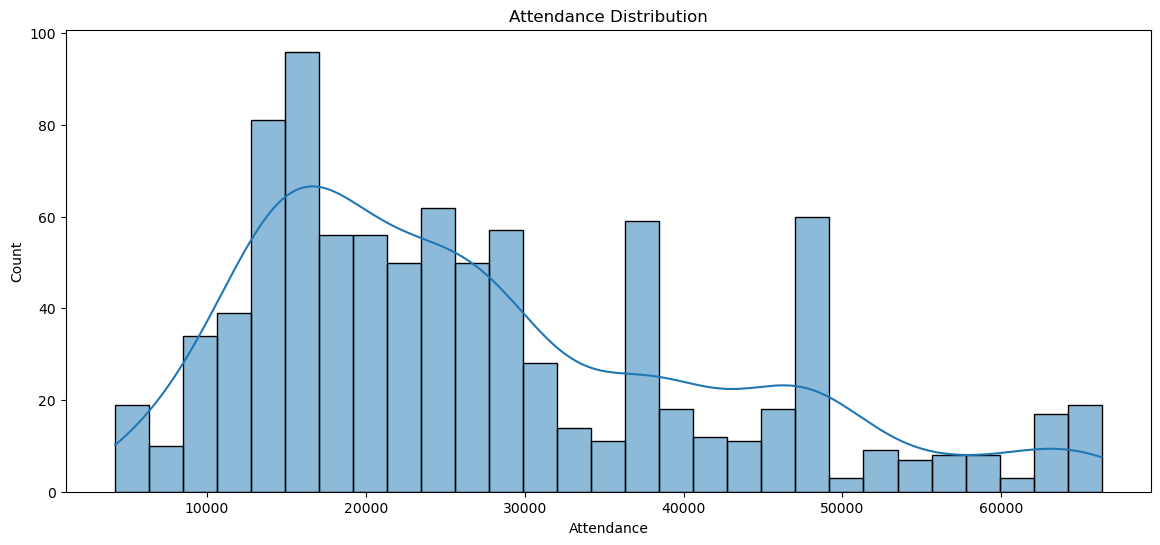

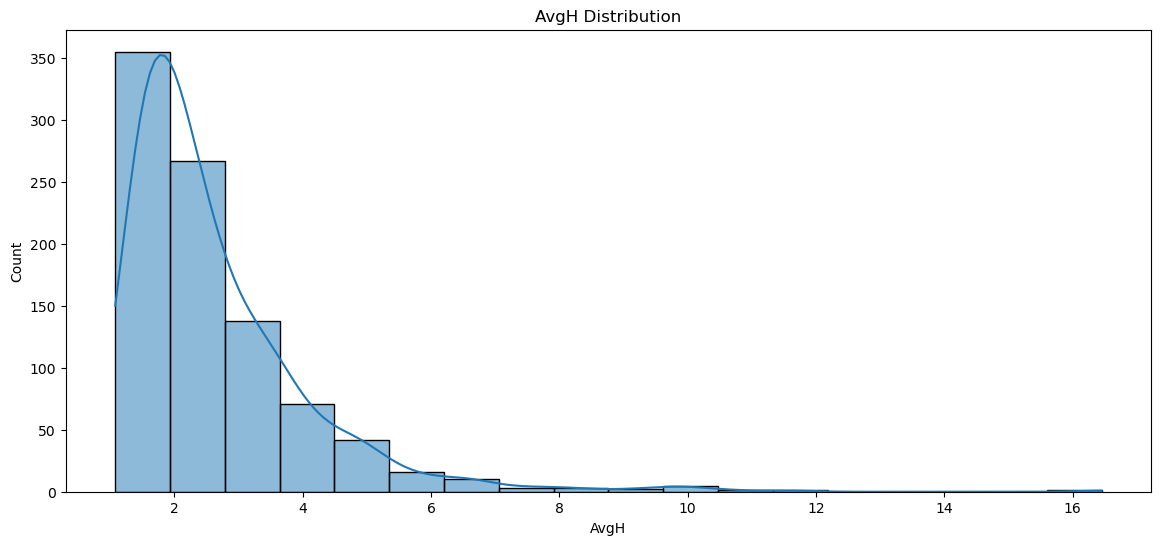

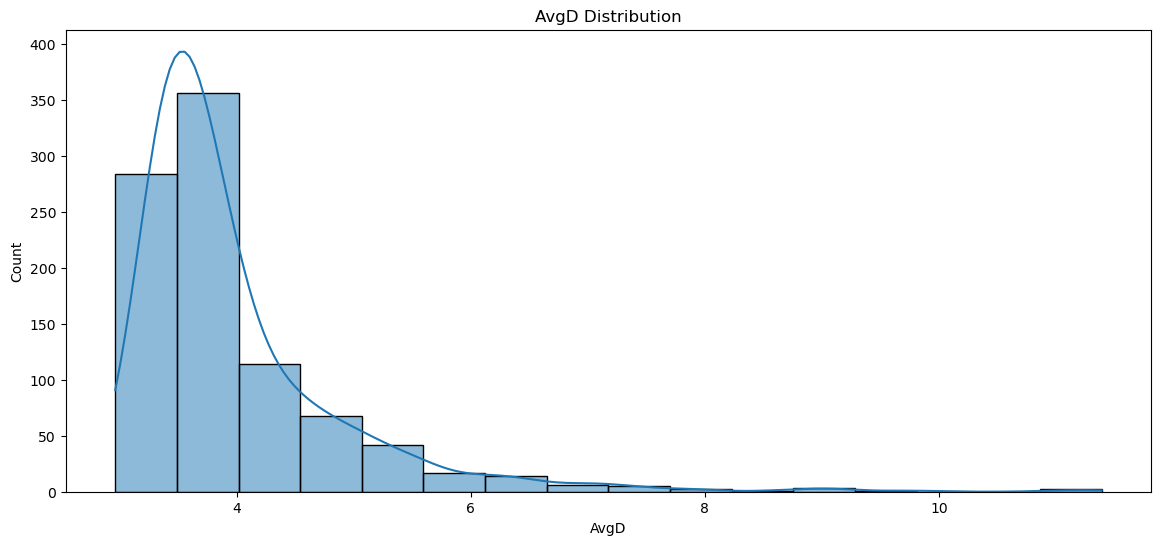

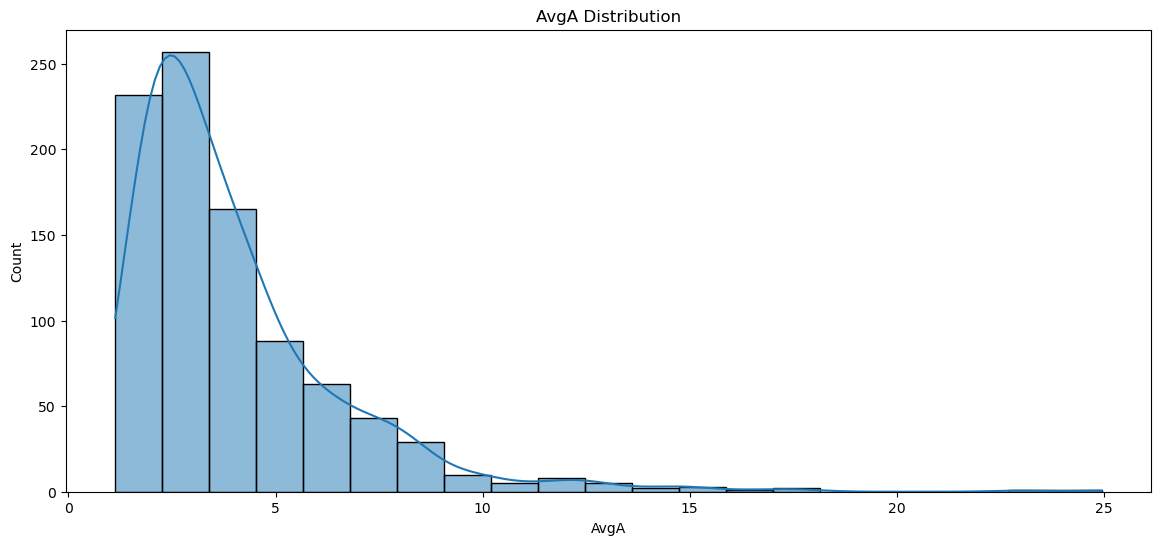

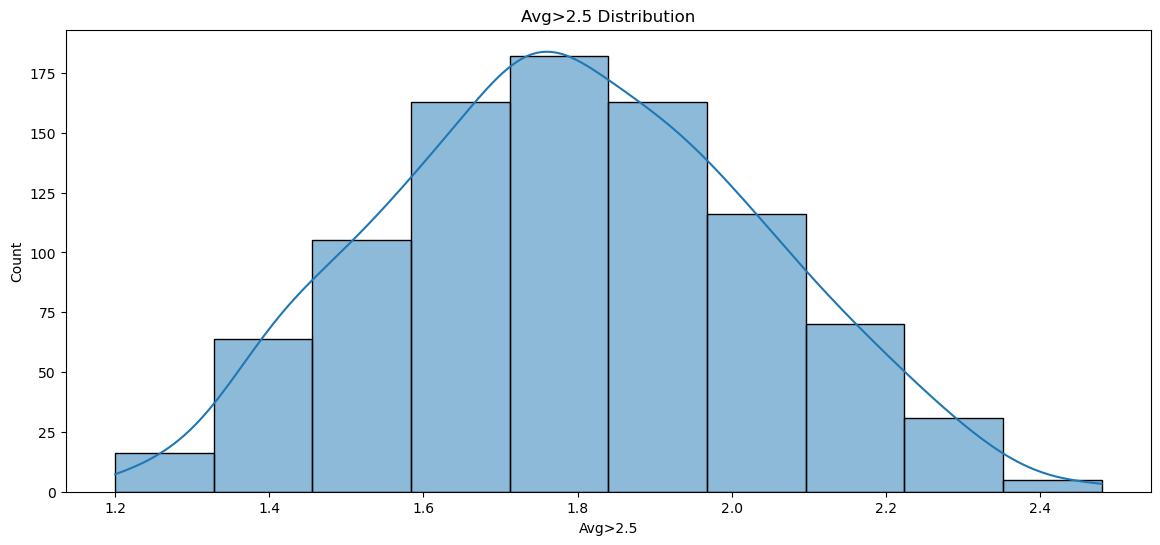

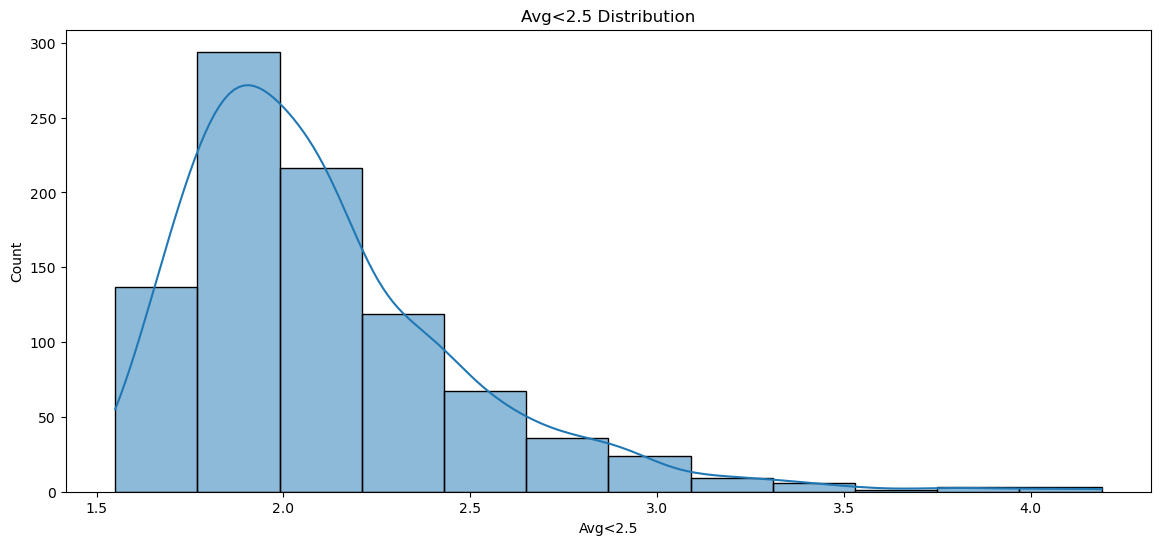

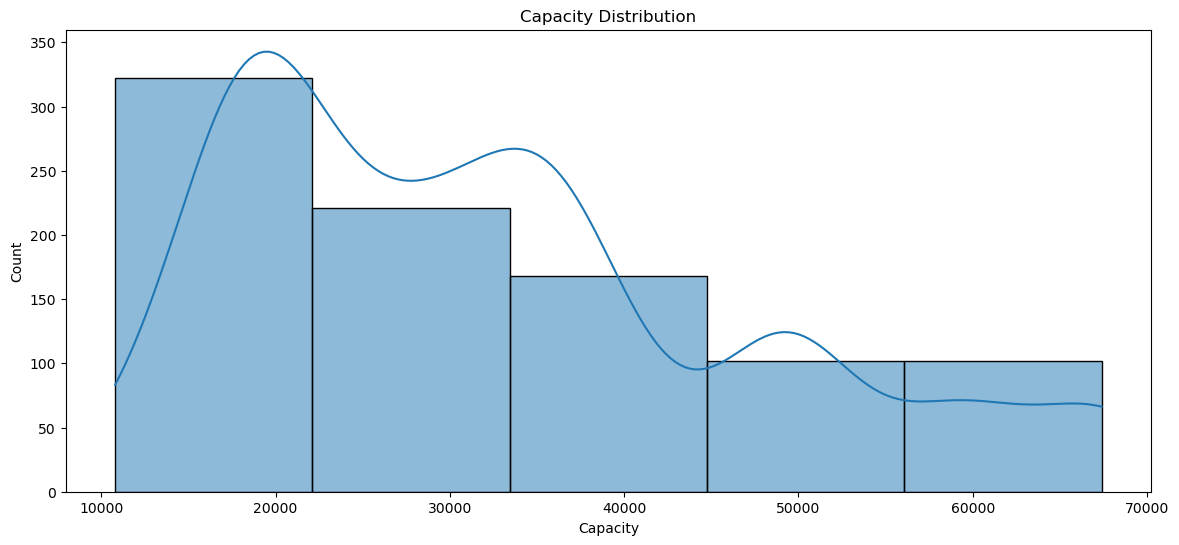

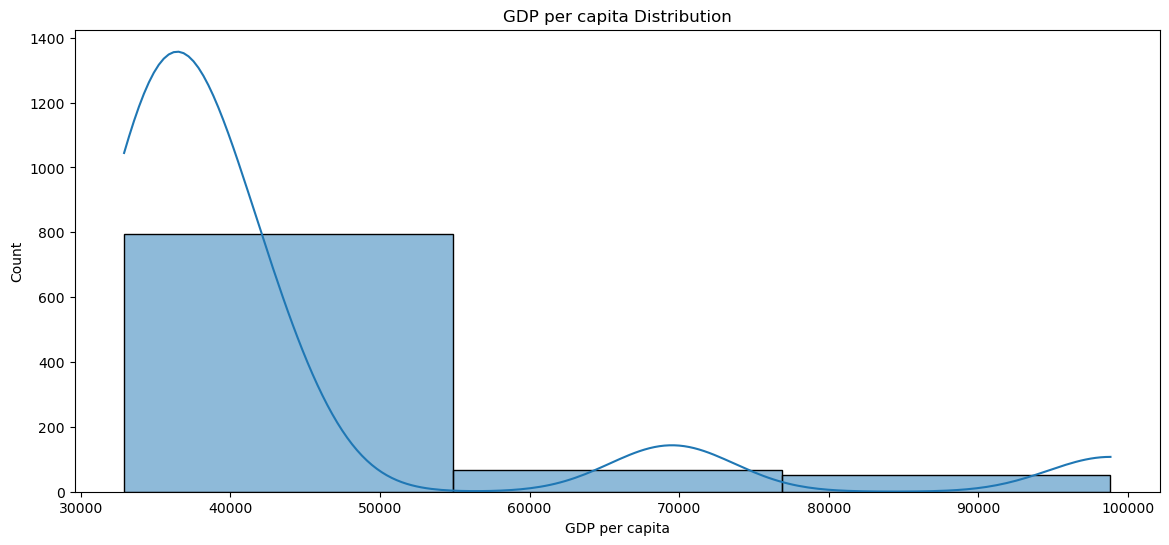

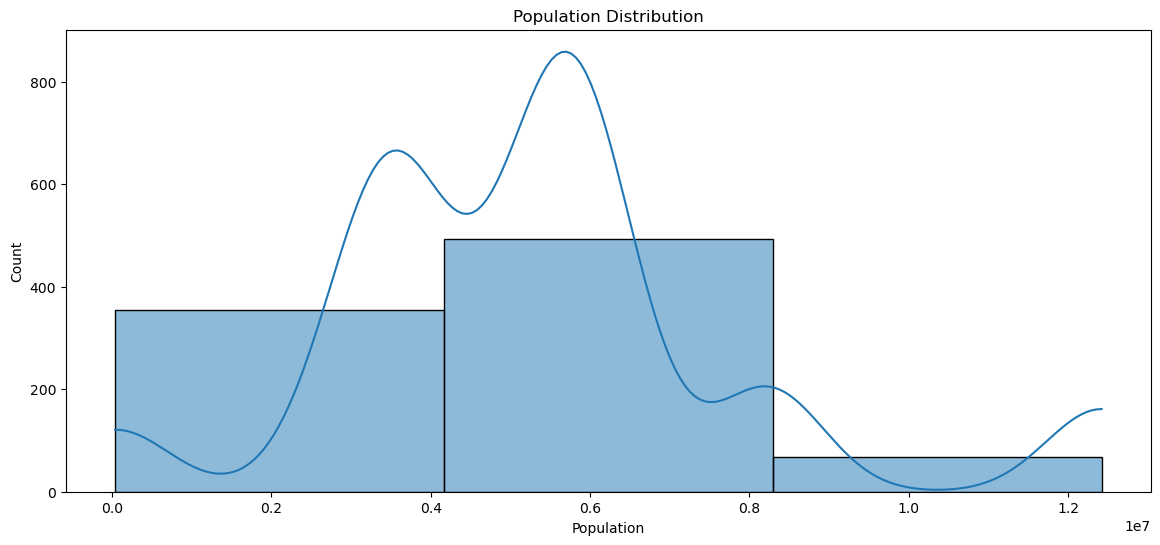

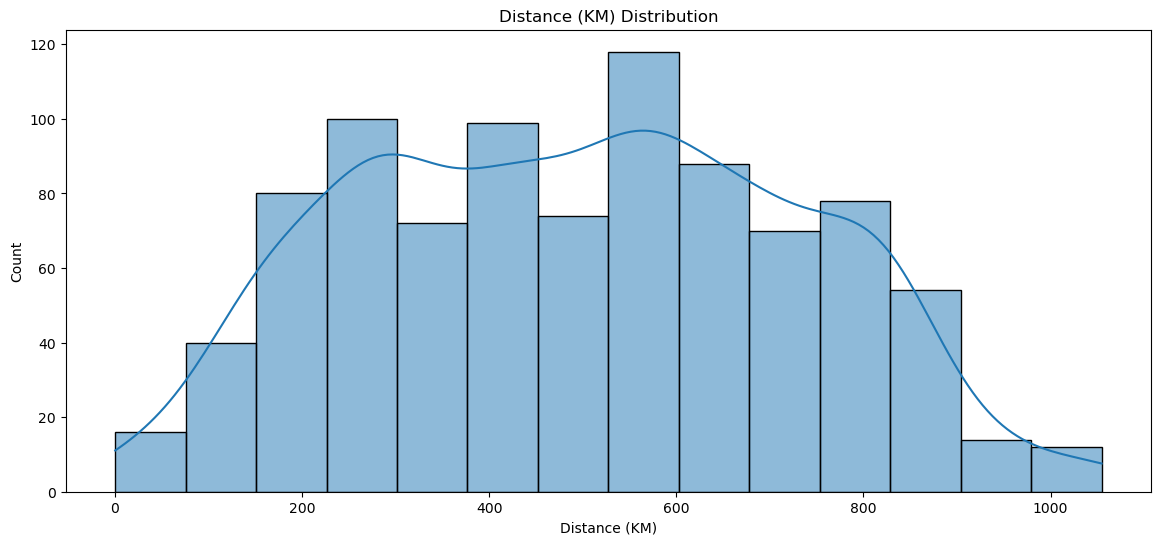

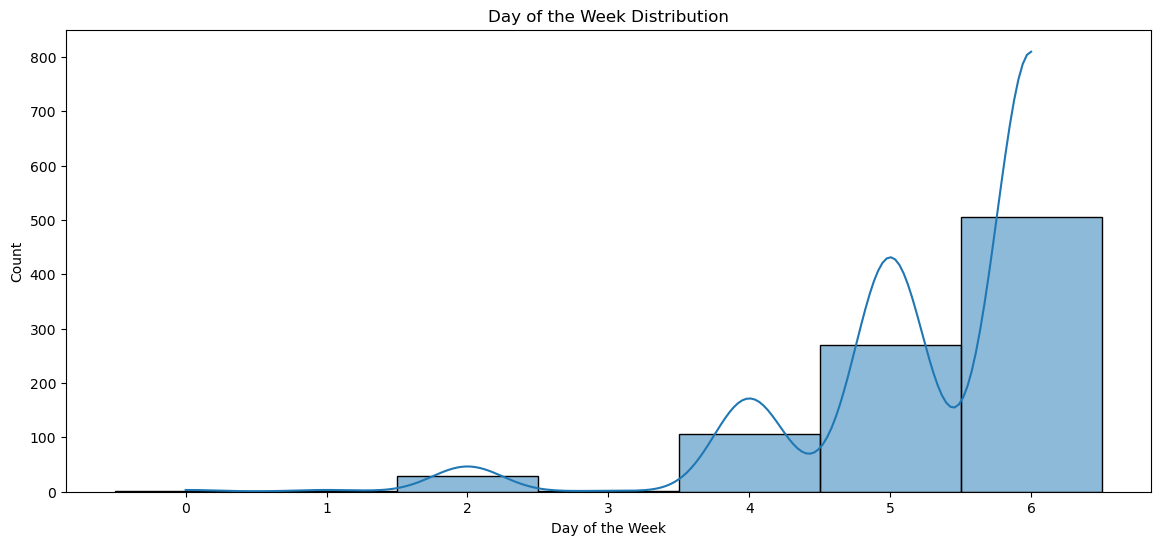

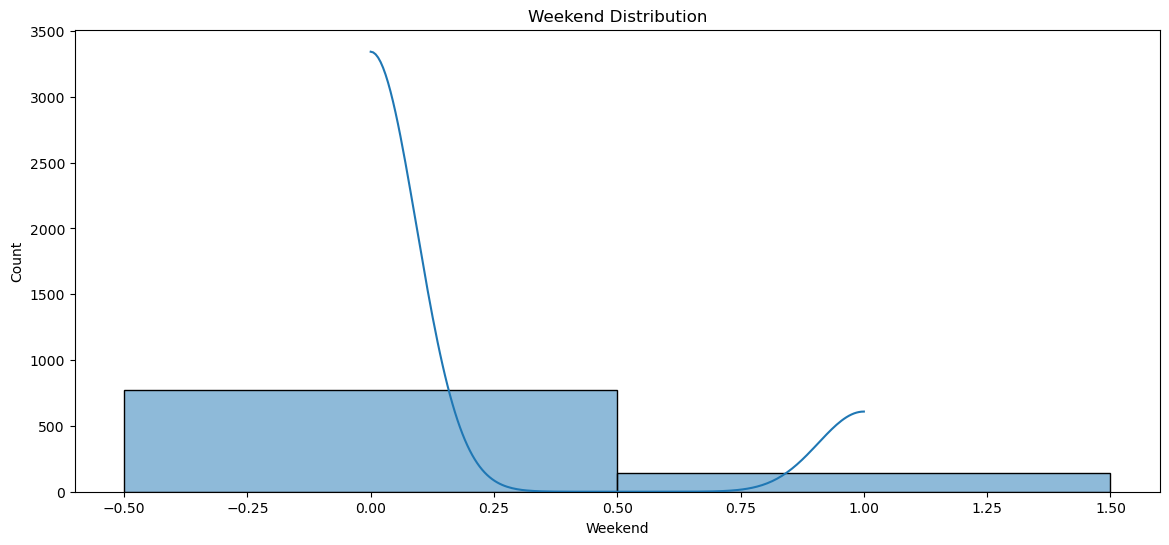

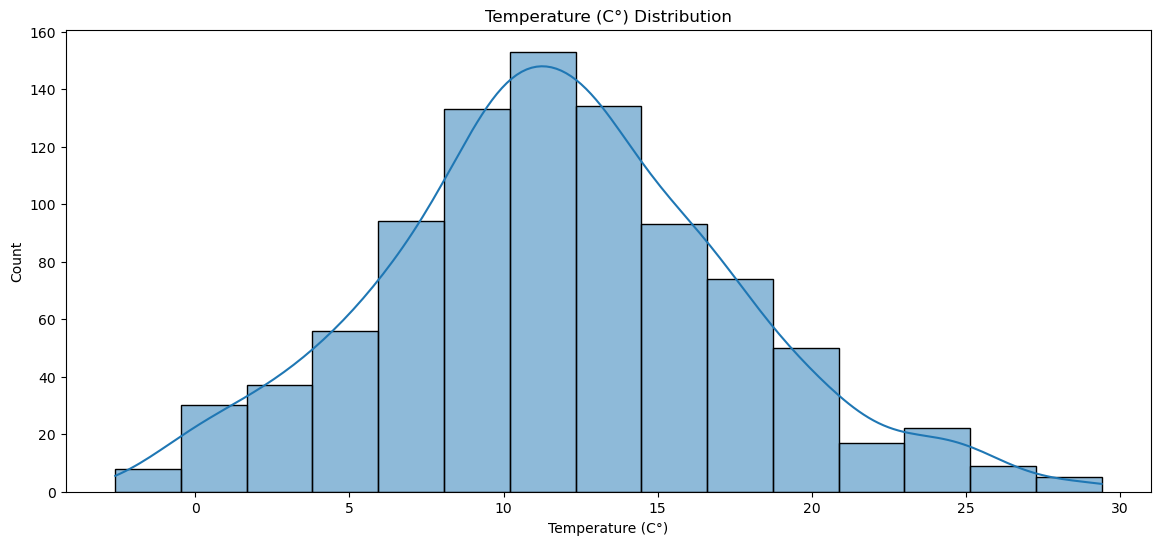

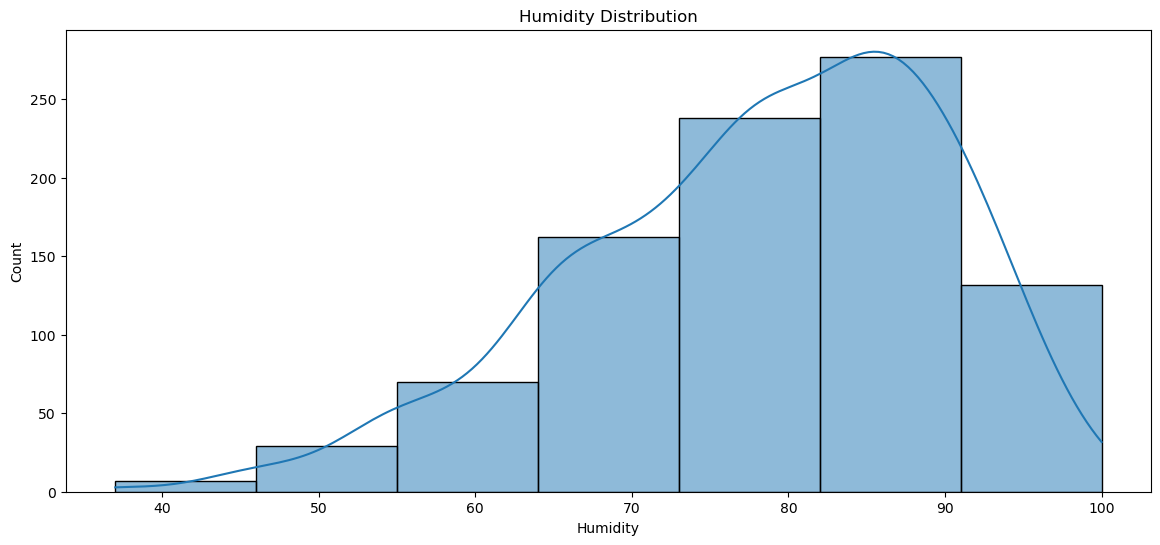

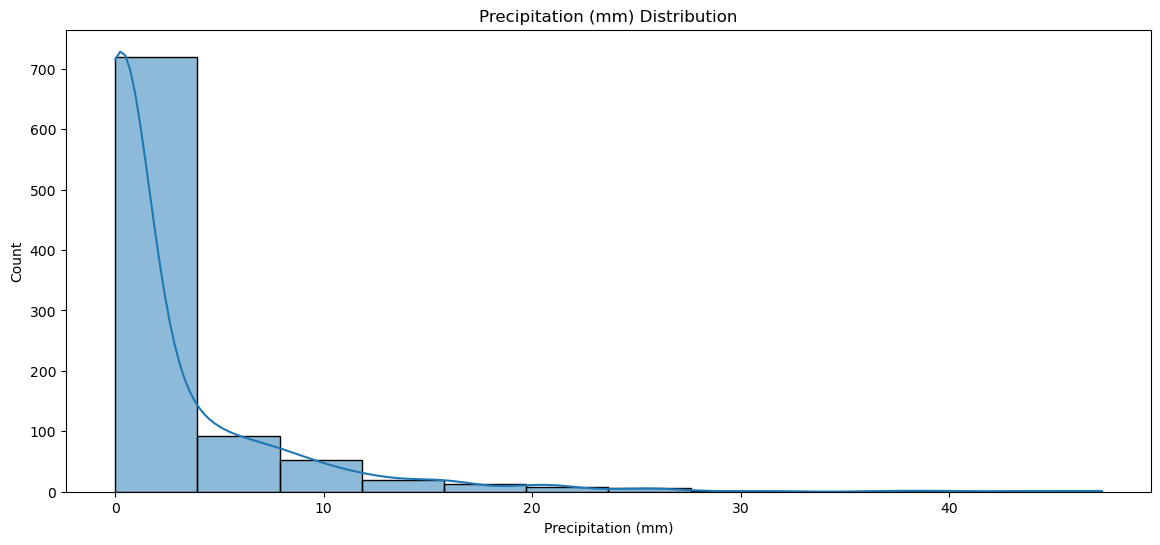

In [6]:
distribution = df[['Attendance', 'AvgH', 'AvgD', 'AvgA', 'Avg>2.5',
       'Avg<2.5', 'Capacity', 'GDP per capita', 'Population', 'Distance (KM)', 'Day of the Week',
       'Weekend', 'Temperature (C°)', 'Humidity', 'Precipitation (mm)',
       ]]
for element in distribution :

    plt.figure(figsize=(14, 6))
    count = df[element].unique().size
    nbins = int(np.sqrt(count))
    sns.histplot(data = df, bins = nbins, 
                 kde = True, x = element)
    plt.title(element + " Distribution")
    plt.show()

In [7]:
#Creating an occupancy rate allows us to normalize the attendance values based on the maximum capacity of each stadium 
df["Occupancy"] = (df["Attendance"]/df["Capacity"])

In [9]:
num = df[['AvgH', 'AvgD', 'AvgA', 'Avg>2.5',
         'Avg<2.5', 'Distance (KM)',
         'Temperature (C°)', 'Humidity', 'Precipitation (mm)']]

cat = df[["Home", "Away", "Day of the Week", "Weekend", "Time", "Region"]]

In [10]:
# ==========================================
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

<Figure size 1400x600 with 0 Axes>

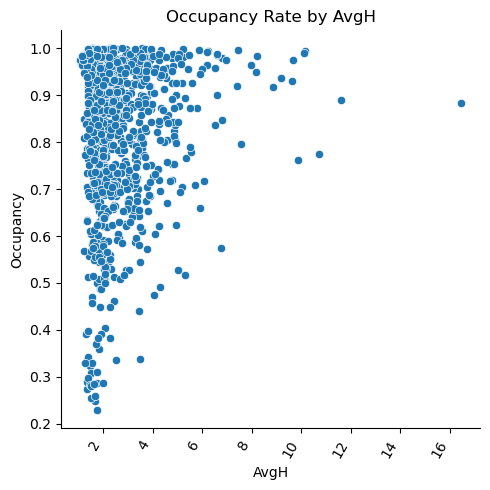

<Figure size 1400x600 with 0 Axes>

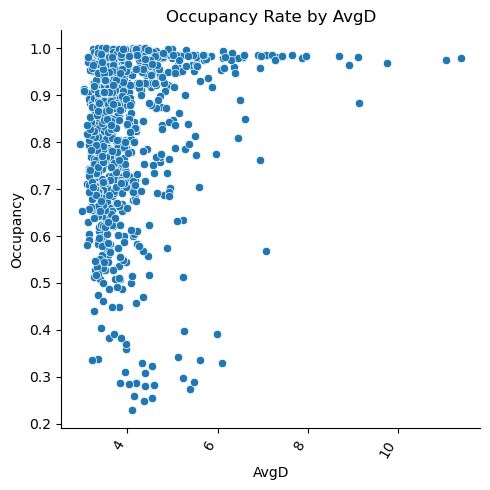

<Figure size 1400x600 with 0 Axes>

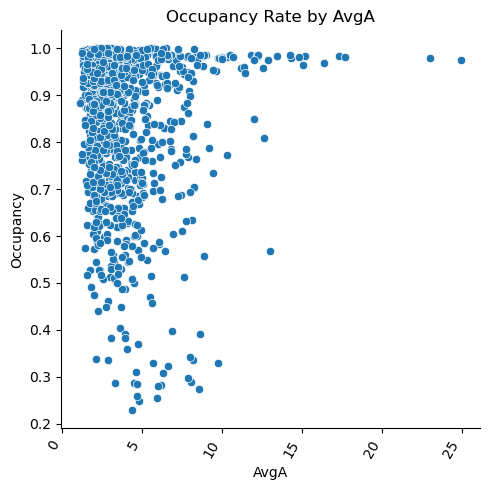

<Figure size 1400x600 with 0 Axes>

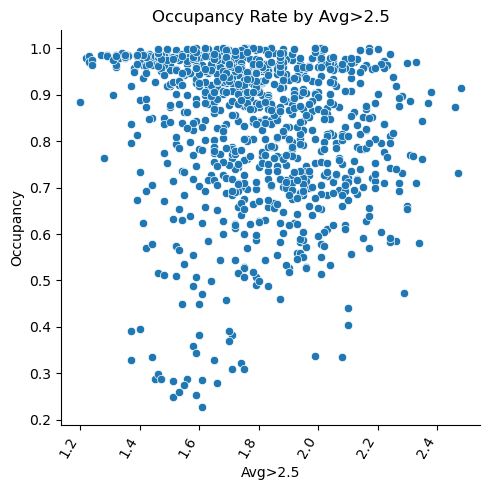

<Figure size 1400x600 with 0 Axes>

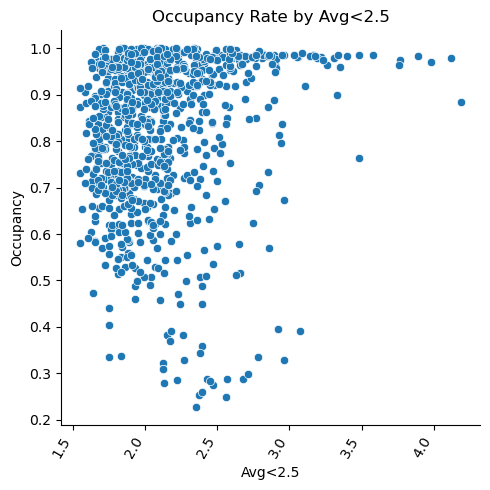

<Figure size 1400x600 with 0 Axes>

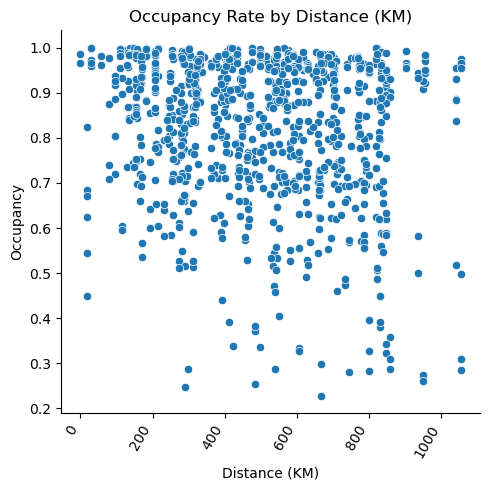

<Figure size 1400x600 with 0 Axes>

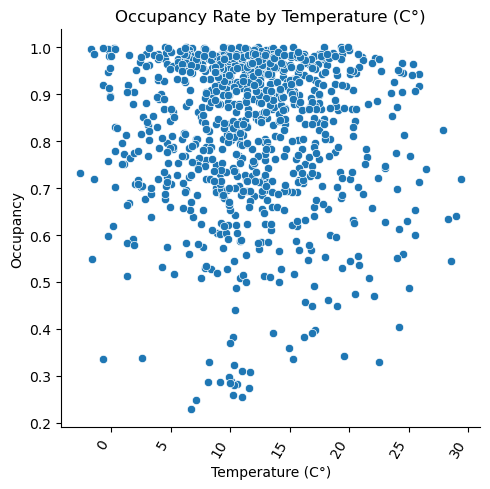

<Figure size 1400x600 with 0 Axes>

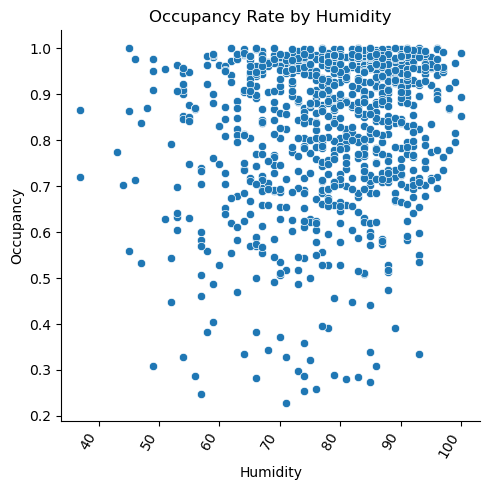

<Figure size 1400x600 with 0 Axes>

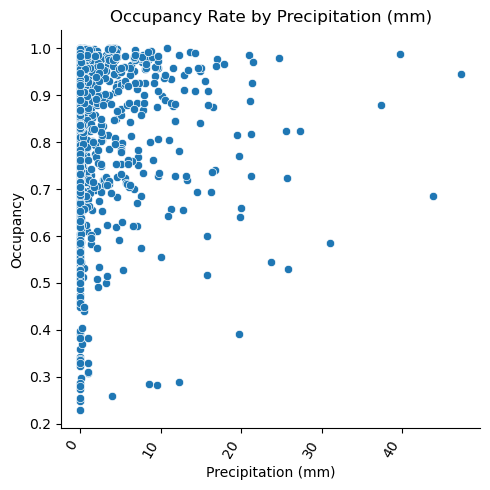

In [19]:
for element in num:
    plt.figure(figsize=(14, 6))
    sns.relplot(data = df, x = element, y = "Occupancy" , kind = "scatter")
    plt.title("Occupancy Rate by " + element)
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    plt.show()

<Figure size 1400x600 with 0 Axes>

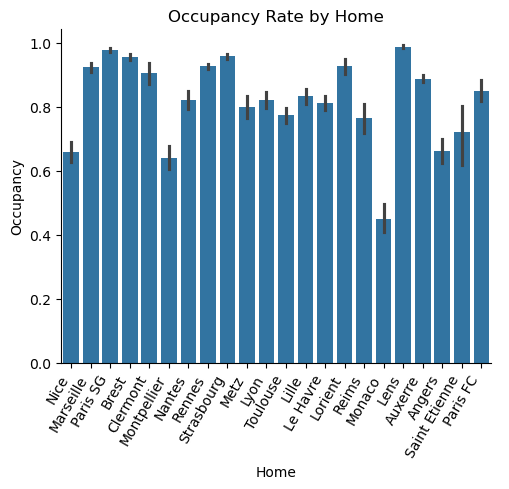

<Figure size 1400x600 with 0 Axes>

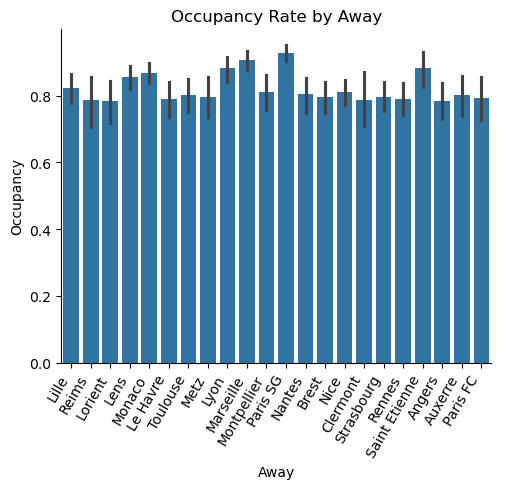

<Figure size 1400x600 with 0 Axes>

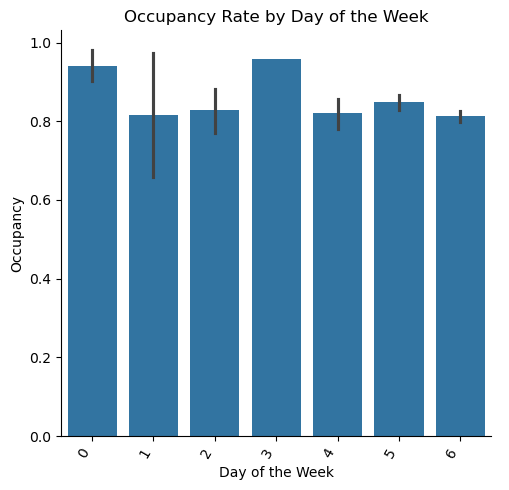

<Figure size 1400x600 with 0 Axes>

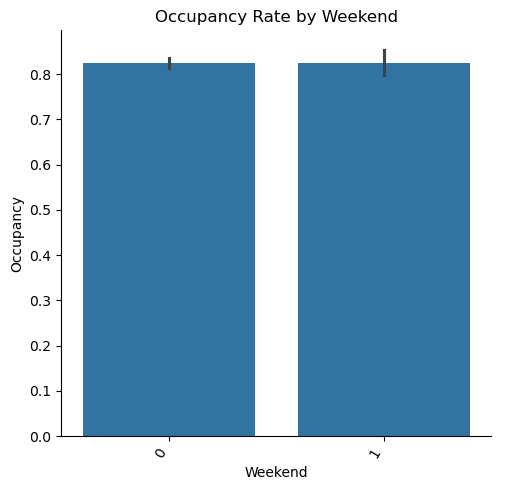

<Figure size 1400x600 with 0 Axes>

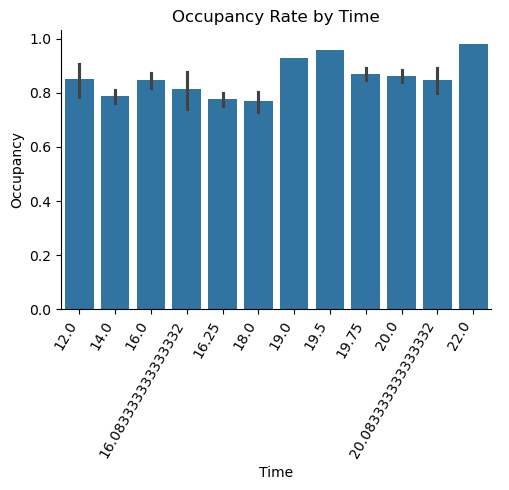

<Figure size 1400x600 with 0 Axes>

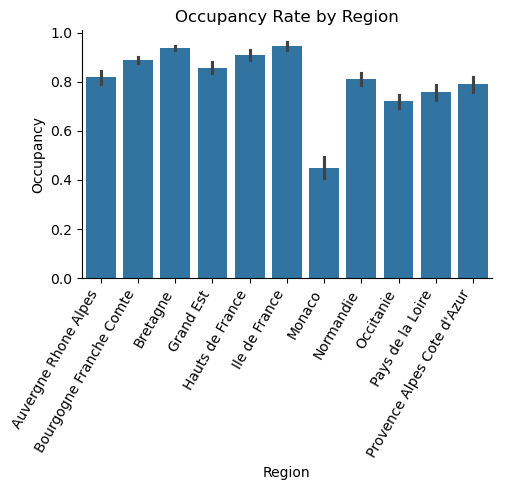

In [12]:
for element in cat:
    plt.figure(figsize=(14, 6))
    sns.catplot(data = df, x = element, y = "Occupancy", kind = "bar")
    plt.title("Occupancy Rate by " + element) 
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    plt.show()

In [13]:
# ==========================================
# 5. LOG TRANSFORMS & NUMERICAL CATEGORY ENCODING
# ==========================================
df_log = df.copy()

# Map categories to underlying integer codes so correlation (.corr()) can read them
for col in categorical_cols:
    df_log[col] = df_log[col].cat.codes

# Apply log transform to heavily skewed continuous variables
columns_to_log = [
    'Attendance', 'AvgH', 'AvgD', 'AvgA', 'Avg<2.5', 
    'Capacity', 'GDP per capita', 'Population', 
    'Distance (KM)', 'Humidity', 'Precipitation (mm)'
]
df_log[columns_to_log] = np.log1p(df_log[columns_to_log])

# Select target and features for correlation and modeling
features_to_analyze = [
    'Attendance', 'Time', 'Stadium', 'Region', 'Day of the Week', 'Weekend',
    'AvgH', 'AvgD', 'AvgA', 'Avg>2.5', 'Avg<2.5', 'Capacity', 
    'GDP per capita', 'Population', 'Distance (KM)', 
    'Temperature (C°)', 'Humidity', 'Precipitation (mm)'
]
log_dist = df_log[features_to_analyze]

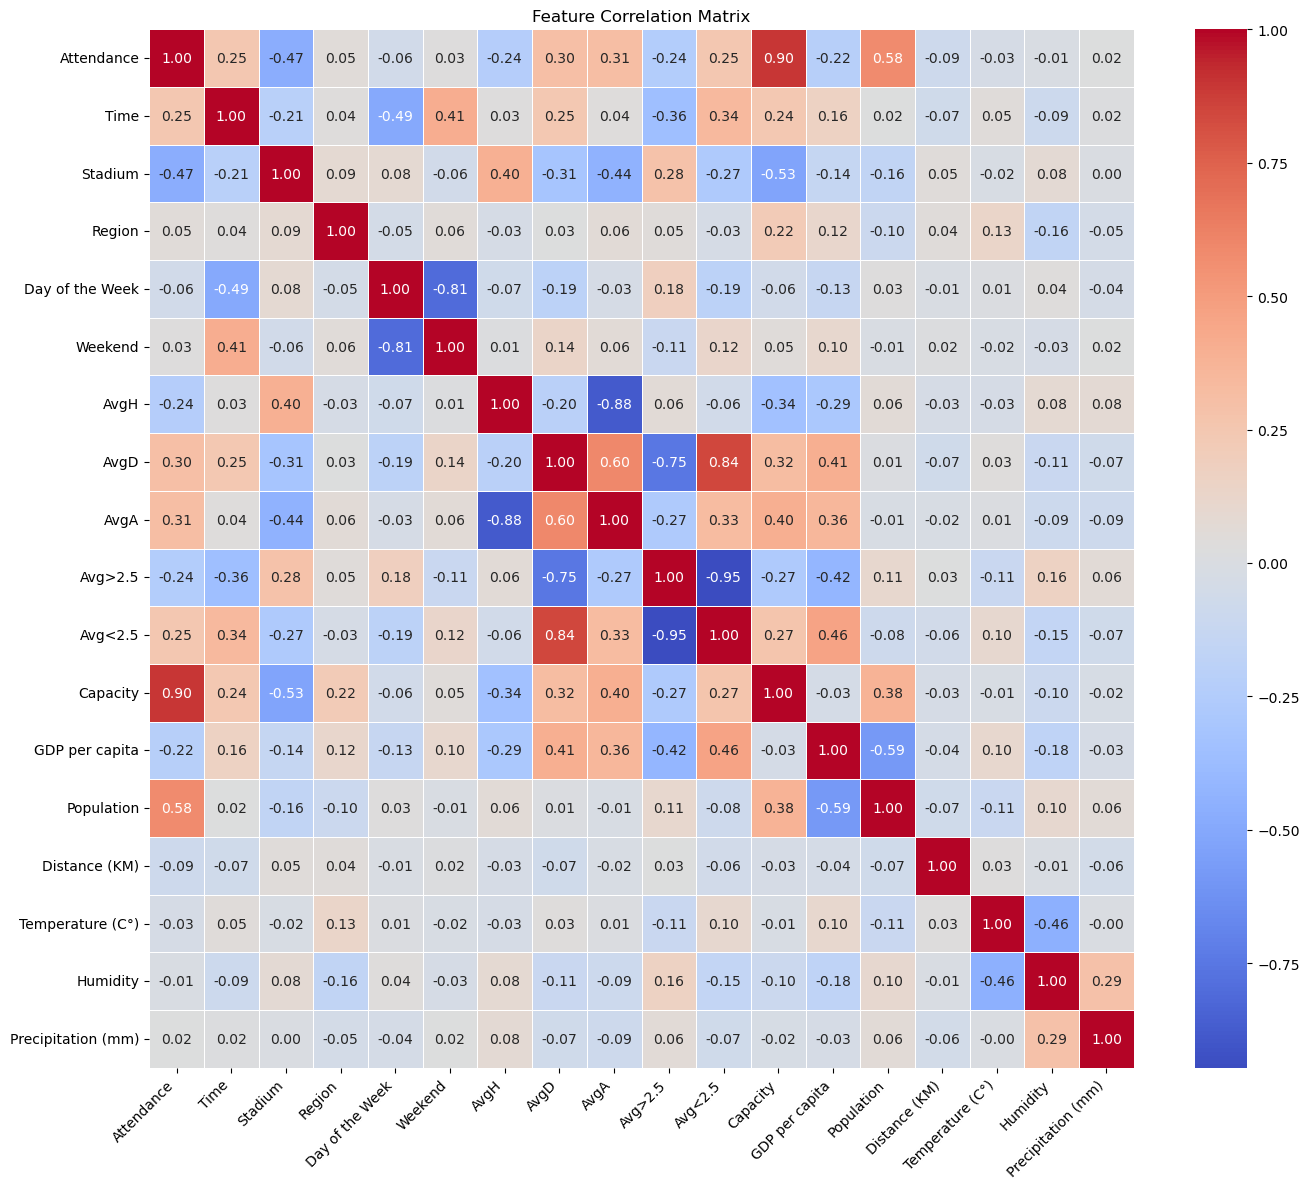

In [14]:
# Correlation Heatmap
corr = log_dist.corr() 
plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.xticks(rotation=45, ha="right")
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [15]:
# ==========================================
# 6. MODELING PREPARATION
# ==========================================
# Set up full feature framework including encoded dimensions
predictors = [
    'Time', 'Day of the Week', 'Weekend', 
    'Avg>2.5', 'Capacity', 'GDP per capita', 'Population', 
    'Distance (KM)', 'AvgH', 'Temperature (C°)', 
    'Humidity', 'Precipitation (mm)'
]

X = log_dist[predictors]
y = log_dist['Attendance']

# 70/30 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [16]:
# ==========================================
# 7. MODEL EVALUATION & VISUALIZATION UTILITIES
# ==========================================
def evaluate_and_plot(model, X_set, y_true_log, model_name):
    """
    Evaluates log-scale model targets, outputs back-transformed metrics,
    and returns a side-by-side diagnostic visualization panel.
    """
    # 1. Inference and Back-Transformations
    preds_log = model.predict(X_set)
    y_true_actual = np.expm1(y_true_log)
    preds_actual = np.expm1(preds_log)
    
    # 2. Score Calculations
    rmse_true = np.sqrt(mean_squared_error(y_true_actual, preds_actual))
    r2_log = r2_score(y_true_log, preds_log)
    mape_log = mean_absolute_percentage_error(y_true_log, preds_log)
    rmse_log = np.sqrt(mean_squared_error(y_true_log, preds_log))
    
    print(f"\n=== {model_name} Performance ===")
    print(f"Log-Scale R2 Score : {r2_log:.4f}")
    print(f"Log-Scale RMSE     : {rmse_log:.4f}")
    print(f"Log-Scale MAPE     : {mape_log:.4f}")
    print(f"-> True Scale Average Seat Error (RMSE): ±{int(rmse_true):,} seats\n")
    
    # 3. Create Clean Diagnostic Subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left subplot: Feature Importance
    importances = pd.DataFrame({
        'Features': X_set.columns,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)
    
    sns.barplot(data=importances, y='Features', x='Importance', ax=axes[0], palette="viridis")
    axes[0].set_title(f'{model_name} - Feature Importance Ranking')
    
    # Right subplot: True vs Predicted Regression Line
    sns.regplot(x=y_true_log, y=preds_log, ax=axes[1], line_kws={"color": "red", "linestyle": "--"})
    axes[1].set_xlabel("Actual Log Attendance")
    axes[1].set_ylabel("Predicted Log Attendance")
    axes[1].set_title(f'{model_name} - Actual vs. Predicted Validation')
    
    plt.tight_layout()
    plt.show()
    
    return importances


=== Random Forest Performance ===
Log-Scale R2 Score : 0.9411
Log-Scale RMSE     : 0.1348
Log-Scale MAPE     : 0.0093
-> True Scale Average Seat Error (RMSE): ±3,390 seats



C:\Users\H.P\AppData\Local\Temp\ipykernel_13660\3549821787.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, y='Features', x='Importance', ax=axes[0], palette="viridis")


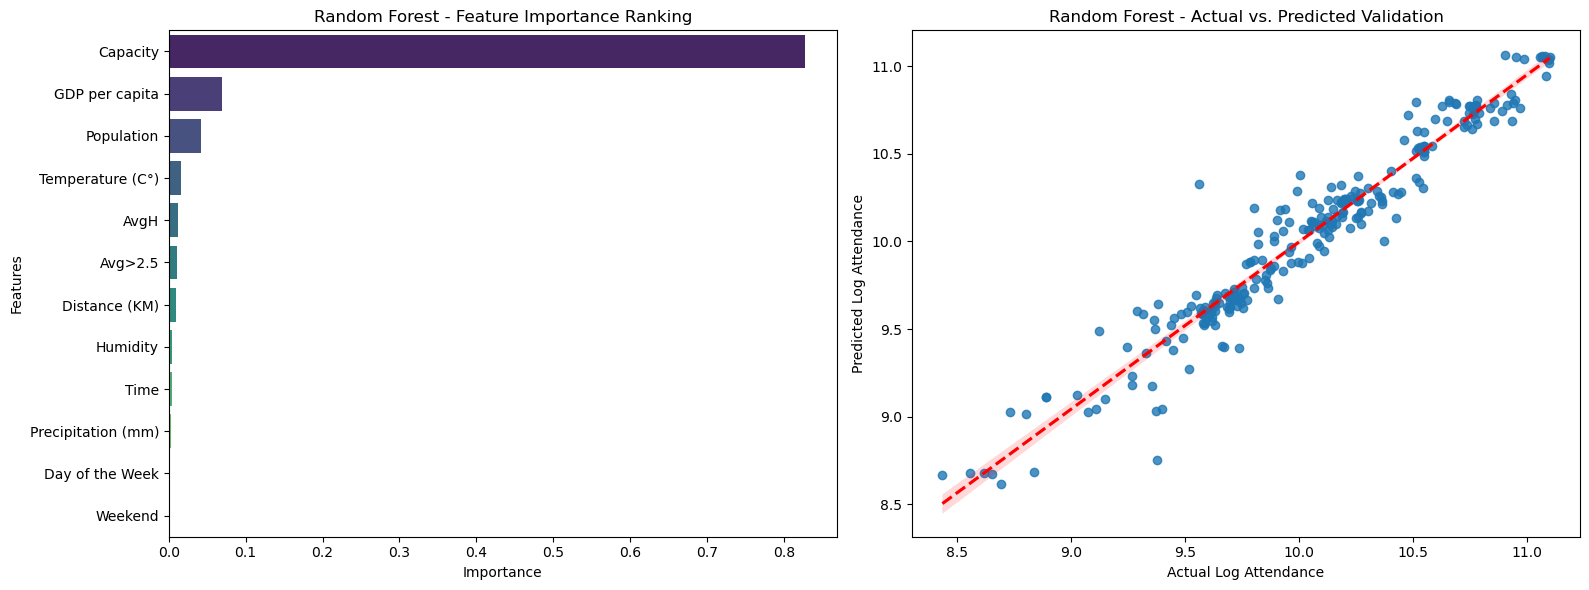


=== XGBoost Performance ===
Log-Scale R2 Score : 0.9524
Log-Scale RMSE     : 0.1211
Log-Scale MAPE     : 0.0088
-> True Scale Average Seat Error (RMSE): ±3,133 seats



C:\Users\H.P\AppData\Local\Temp\ipykernel_13660\3549821787.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, y='Features', x='Importance', ax=axes[0], palette="viridis")


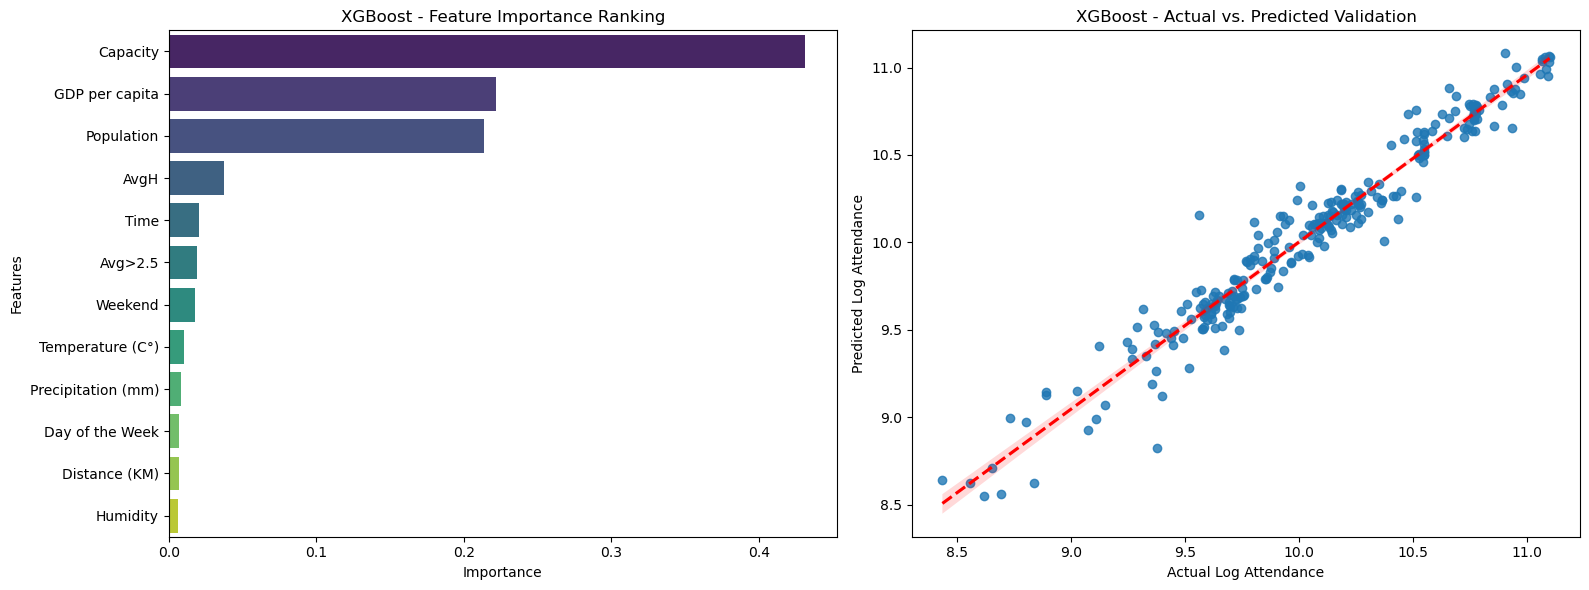

In [17]:
# ==========================================
# 8. REGRESSION PIPELINE EXECUTION
# ==========================================

# --- Model A: Random Forest Regressor ---
rf_model = RandomForestRegressor(
    n_estimators=200,      
    max_depth=12,          
    random_state=42,
    n_jobs=-1              
)
rf_model.fit(X_train, y_train)
rf_importances = evaluate_and_plot(rf_model, X_test, y_test, "Random Forest")

# --- Model B: XGBoost Regressor ---
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,    
    subsample=0.8,          
    colsample_bytree=0.8,  
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
xgb_importances = evaluate_and_plot(xgb_model, X_test, y_test, "XGBoost")